# Curriculum Learning with VGG-style CNN (CIFAR-10)

This experiment implements curriculum learning based on prediction difficulty.

## Strategy:
1. Train a scorer model
2. Rank samples by difficulty (cross-entropy loss)
3. Train VGG-style model from easy → hard in stages

## Dataset:
- 50,000 training images
- 10,000 test images
- 10 classes

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

## Data Preprocessing

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_set = test_datagen.flow(x_test, y_test, batch_size=64)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


## VGG-style CNN Architecture

In [4]:
def build_vgg():

    model = models.Sequential()

    model.add(layers.Input(shape=(32,32,3)))

    # Block 1
    model.add(layers.Conv2D(64,3,padding='same',activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64,3,padding='same',activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2))

    # Block 2
    model.add(layers.Conv2D(128,3,padding='same',activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128,3,padding='same',activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2))

    # Block 3
    model.add(layers.Conv2D(256,3,padding='same',activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(256,3,padding='same',activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2))

    # Dense
    model.add(layers.Flatten())
    model.add(layers.Dense(512,activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10,activation='softmax'))

    return model

## Step 1: Train Scorer Model

In [5]:
scorer = build_vgg()
scorer.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

scorer.summary()

scorer.fit(train_datagen.flow(x_train,y_train,batch_size=64), epochs=3)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,251,786 (12.40 MB)

 Trainable params: 3,249,994 (12.40 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 51ms/step - accuracy: 0.4179 - loss: 1.6790
Epoch 2/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.5787 - loss: 1.2067
Epoch 3/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.6599 - loss: 1.0001


## Step 2: Compute Difficulty Scores

In [6]:
x_train_norm = x_train.astype('float32')/255.0
preds = scorer.predict(x_train_norm, batch_size=256)

per_sample_loss = np.zeros(len(x_train))

for i in range(len(x_train)):
    label = int(y_train[i][0])
    prob = np.clip(preds[i][label],1e-7,1.0)
    per_sample_loss[i] = -np.log(prob)

196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step


## Step 3: Sort Data (Easy → Hard)

In [7]:
order = np.argsort(per_sample_loss)

x_train_sorted = x_train[order]
y_train_sorted = y_train[order]
loss_sorted = per_sample_loss[order]

## Visualizing Difficulty Distribution

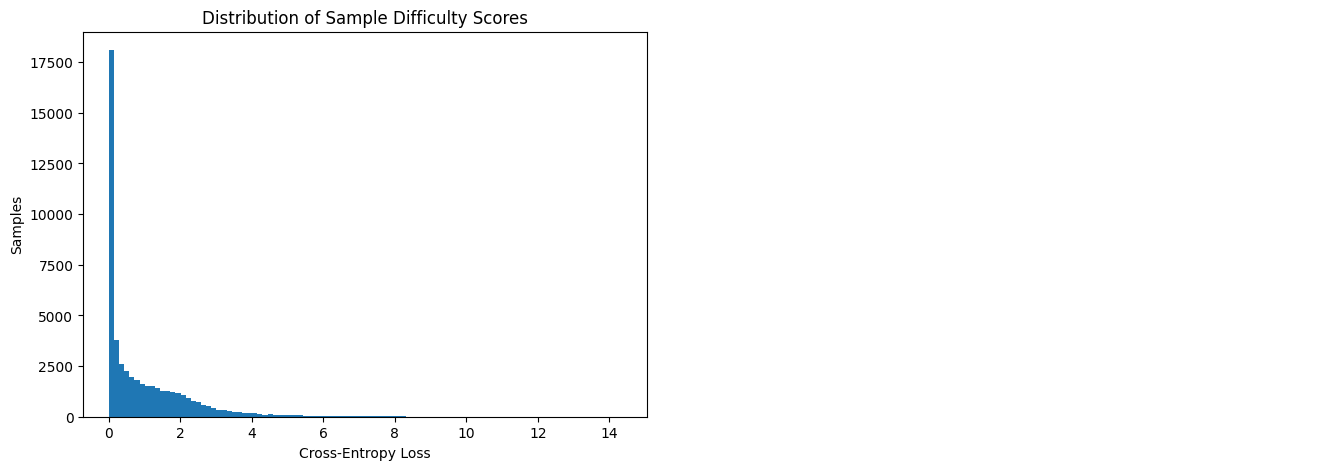

/tmp/ipykernel_1527/1472712026.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  axes[0,i].set_title(class_names[int(y_train_sorted[i])])
/tmp/ipykernel_1527/1472712026.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  axes[1,i].set_title(class_names[int(y_train_sorted[-(i+1)])])


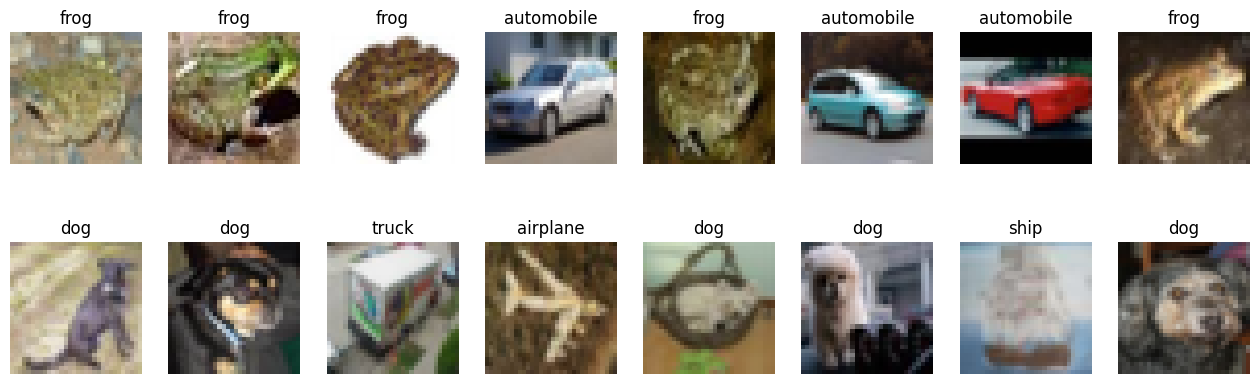

In [8]:
fig, axes = plt.subplots(1,2,figsize=(16,5))

axes[0].hist(per_sample_loss, bins=100)
axes[0].set_title("Distribution of Sample Difficulty Scores")
axes[0].set_xlabel("Cross-Entropy Loss")
axes[0].set_ylabel("Samples")

axes[1].axis('off')

plt.show()

fig, axes = plt.subplots(2,8,figsize=(16,5))

for i in range(8):
    axes[0,i].imshow(x_train_sorted[i])
    axes[0,i].set_title(class_names[int(y_train_sorted[i])])
    axes[0,i].axis('off')

    axes[1,i].imshow(x_train_sorted[-(i+1)])
    axes[1,i].set_title(class_names[int(y_train_sorted[-(i+1)])])
    axes[1,i].axis('off')

plt.show()

## Curriculum Learning Training (Easy → Hard)

In [9]:
curriculum_fractions = [0.2,0.4,0.6,0.8,1.0]
epochs_per_stage = 5

cnn = build_vgg()
cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0008),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

cnn.summary()

full_history = {'accuracy':[],'val_accuracy':[],'loss':[],'val_loss':[]}
stage_boundaries = []

for i, frac in enumerate(curriculum_fractions):

    n = int(len(x_train_sorted)*frac)

    x_subset = x_train_sorted[:n]
    y_subset = y_train_sorted[:n]

    training_set = train_datagen.flow(x_subset,y_subset,batch_size=64)

    print("\n"+"="*60)
    print(f"STAGE {i+1}: {frac*100:.0f}% data ({n} samples)")
    print("="*60)

    stage_boundaries.append(len(full_history['accuracy']))

    hist = cnn.fit(training_set, validation_data=test_set, epochs=epochs_per_stage)

    for k in full_history:
        full_history[k].extend(hist.history[k])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,251,786 (12.40 MB)

 Trainable params: 3,249,994 (12.40 MB)

 Non-trainable params: 1,792 (7.00 KB)


STAGE 1: 20% data (10000 samples)
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 91ms/step - accuracy: 0.7140 - loss: 1.0886 - val_accuracy: 0.1072 - val_loss: 6.9261
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.8499 - loss: 0.4473 - val_accuracy: 0.1032 - val_loss: 10.7166
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.8951 - loss: 0.3266 - val_accuracy: 0.3130 - val_loss: 5.5419
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.9266 - loss: 0.2239 - val_accuracy: 0.4987 - val_loss: 4.0953
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.9516 - loss: 0.1537 - val_accuracy: 0.3707 - val_loss: 6.6966

STAGE 2: 40% data (20000 samples)
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.8656 - loss: 0.4261 - val_accuracy: 0.4532 - val_loss: 3.3452
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.9064 - loss: 0.2973 - val_accuracy: 0.5484 - val_loss: 2.9447
Epoch 3/5
313/313 ━━━━━━━━━━━━

## Training Results Visualization

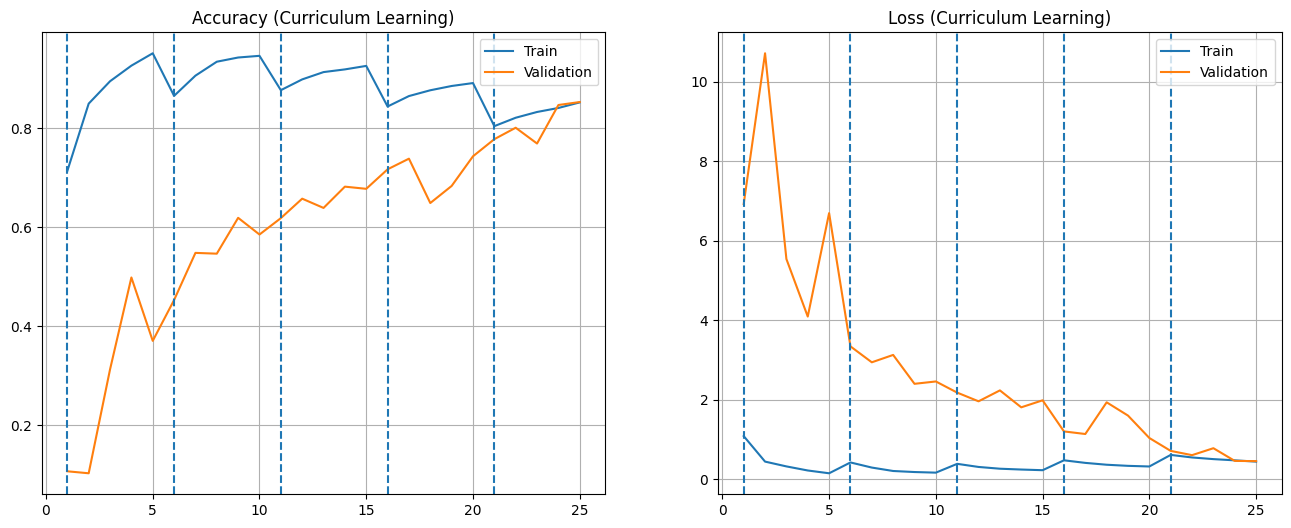

In [10]:
epochs = range(1,len(full_history['accuracy'])+1)

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,6))

ax1.plot(epochs,full_history['accuracy'],label='Train')
ax1.plot(epochs,full_history['val_accuracy'],label='Validation')

for b in stage_boundaries:
    ax1.axvline(b+1, linestyle='--')

ax1.set_title("Accuracy (Curriculum Learning)")
ax1.legend()
ax1.grid(True)

ax2.plot(epochs,full_history['loss'],label='Train')
ax2.plot(epochs,full_history['val_loss'],label='Validation')

for b in stage_boundaries:
    ax2.axvline(b+1, linestyle='--')

ax2.set_title("Loss (Curriculum Learning)")
ax2.legend()
ax2.grid(True)

plt.show()

## Final Test Evaluation

In [11]:
test_loss, test_acc = cnn.evaluate(x_test/255.0,y_test)

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

cnn.save("curriculum_vgg.keras")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8531 - loss: 0.4591

Test Loss     : 0.4591
Test Accuracy : 0.8531


## Single Image Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted: automobile
Actual: automobile


/tmp/ipykernel_1527/4172184092.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual = int(y_test[idx])


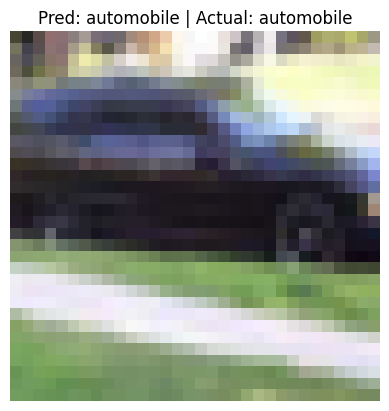

In [12]:
idx = np.random.randint(0,len(x_test))
img = x_test[idx]

input_img = np.expand_dims(img/255.0,axis=0)

pred = cnn.predict(input_img)

pred_class = np.argmax(pred[0])
actual = int(y_test[idx])

print("Predicted:",class_names[pred_class])
print("Actual:",class_names[actual])

plt.imshow(img)
plt.title(f"Pred: {class_names[pred_class]} | Actual: {class_names[actual]}")
plt.axis('off')
plt.show()